# Setup

### Imports

In [1]:
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import cloudpickle

### Constants

In [2]:
SEED = 42
FEATURES = ["temperature", "humidity", "wind_direction", "wind_speed", "precipitation", "light"]

### Set splitting

In [3]:
def split_set(X, y, seed):
    X_tune, X_test, y_tune, y_test = train_test_split(X, y, test_size=.2, random_state=seed)
    X_train, X_validate, y_train, y_validate = train_test_split(X_tune, y_tune, test_size=.2, random_state=seed)
    return ((X_train, y_train), (X_validate, y_validate), (X_test, y_test))

In [4]:
def get_sets(data, seed=42, do_split=True, drop_y_nan=True):
    y_labels = [label for label in data.columns if label.startswith("future_")]

    if drop_y_nan:
        data = data.dropna(subset=y_labels)
    X = data.drop([*y_labels], axis="columns")
    y = data[y_labels]

    if do_split:
        return split_set(X, y, seed)
    else:
        return (X, y)

### Metrics

In [5]:
from sklearn.metrics import r2_score, root_mean_squared_error

def compute_metrics(estimator, sets):
    n_features = sets[0][2].shape[1]
    metrics = [("r2", r2_score), ("RMSE", root_mean_squared_error)]
    metric_outputs = {"feature": [*(sets[0][2].iloc[:, i].name for i in range(n_features)), "all"]}
    predictions = [estimator.predict(set[1]) for set in sets]

    for metric_label, metric in metrics:
        for set_idx, (set_label, _, y) in enumerate(sets):
            for feature_idx in range(n_features):
                metric_outputs.setdefault(f"{metric_label}_{set_label}", [])
                metric_outputs[f"{metric_label}_{set_label}"].append(metric(y.iloc[:, feature_idx], [row[feature_idx] for row in predictions[set_idx]]))
            metric_outputs[f"{metric_label}_{set_label}"].append(metric(y, predictions[set_idx]))
    print(pd.DataFrame(metric_outputs))

def fit_and_score(model, sets):
    model.fit(*(sets[0]))
    compute_metrics(model, [("train", *(sets[0])), ("validate", *(sets[1]))])


### Plotting

In [6]:
def plot_predictions(model, input, hours, just: list[str] | None = None):
    labels = input.columns.to_list()
    labels.remove("time")


    rows = []
    for row in input.iloc:
        rows.extend([row] * hours)
    inputs = pd.DataFrame(rows, columns=input.columns)
    inputs["prediction_offset"] = list(range(hours)) * len(input)
    predictions = model.predict(inputs)

    if just is not None:
        allowed_outputs = [labels.index(output) for output in just]
        old_predictions = predictions
        predictions = []
        for row in old_predictions:
            prediction_row = []
            for i, prediction in enumerate(row):
                if i in allowed_outputs:
                    prediction_row.append(prediction)
            predictions.append(prediction_row)
        labels = just

    plt.figure()
    plt.plot(range(hours), predictions)
    plt.legend(labels)
    plt.show()

### Pipeline functions

In [7]:
def drop_columns(X, columns):
    return X.drop(columns, axis="columns", errors="ignore")

def drop_nan(X):
    return X.dropna()

def move_column(X, idx, col_name):
    column_to_move = X.pop(col_name)
    X.insert(idx, col_name, column_to_move)
    return X

def rename_columns(X, name_map):
    return X.rename(columns=name_map)

def drop_before(X, before_date):
    return X.drop(X[X["time"] < before_date.timestamp()].index)

def drop_after(X, after_date):
    return X.drop(X[X["time"] >= after_date.timestamp()].index)

def _encode_cyclic(value, range_start, range_stop):
    value = (value - range_start) / (range_stop - range_start)
    x = np.sin(2 * np.pi * value)
    y = np.cos(2 * np.pi * value)
    return x, y

def encode_cyclic(X, feature, range_start, range_stop, new_feature_suffix=None, remove_old=False, get_feature=None):
    if get_feature is None:
        def get_feature(row):
            return row[feature]
    if new_feature_suffix is None:
        new_feature_suffix = feature
    X[f"{new_feature_suffix}_sin"] = X[[feature]].apply(lambda row: _encode_cyclic(get_feature(row), range_start, range_stop)[0], axis="columns")
    X[f"{new_feature_suffix}_cos"] = X[[feature]].apply(lambda row: _encode_cyclic(get_feature(row), range_start, range_stop)[1], axis="columns")
    if remove_old:
        X.drop([feature], inplace=True)
    return X

def split_time(X, year=True, month=True, day=True, hour=True, minute=False, second=False, make_cyclic=False, remove_old=True):
    X = X.copy()
    if year:
        X["year"] = X[["time"]].apply(lambda row: datetime.fromtimestamp(row["time"]).year, axis="columns")
    if month:
        if not make_cyclic:
            X["month"] = X[["time"]].apply(lambda row: datetime.fromtimestamp(row["time"]).month, axis="columns")
        else:
            encode_cyclic(X, "time", 1, 12, new_feature_suffix="month", get_feature=lambda row: datetime.fromtimestamp(row["time"]).month)
    if day:
        if not make_cyclic:
            X["day"] = X[["time"]].apply(lambda row: datetime.fromtimestamp(row["time"]).day, axis="columns")
        else:
            encode_cyclic(X, "time", 1, 31, new_feature_suffix="day", get_feature=lambda row: datetime.fromtimestamp(row["time"]).day)
    if hour:
        if not make_cyclic:
            X["hour"] = X[["time"]].apply(lambda row: datetime.fromtimestamp(row["time"]).hour, axis="columns")
        else:
            encode_cyclic(X, "time", 0, 23, new_feature_suffix="hour", get_feature=lambda row: datetime.fromtimestamp(row["time"]).hour)
    if minute:
        if not make_cyclic:
            X["minute"] = X[["time"]].apply(lambda row: datetime.fromtimestamp(row["time"]).minute, axis="columns")
        else:
            encode_cyclic(X, "time", 0, 59, new_feature_suffix="minute", get_feature=lambda row: datetime.fromtimestamp(row["time"]).minute)
    if second:
        if not make_cyclic:
            X["second"] = X[["time"]].apply(lambda row: datetime.fromtimestamp(row["time"]).second, axis="columns")
        else:
            encode_cyclic(X, "time", 0, 59, new_feature_suffix="second", get_feature=lambda row: datetime.fromtimestamp(row["time"]).second)


    if remove_old:
        X.drop(["time"], axis="columns", inplace=True)

    return X

### Read data

In [8]:
raw_data = pd.read_parquet(Path("../data/historical_data_06102.parquet"))
raw_data_limited = raw_data.dropna().sample(n=100000, random_state=SEED)
sets_limited = get_sets(raw_data_limited, seed=SEED)
raw_data_ultra_limited = drop_before(raw_data.dropna(), datetime.now() - timedelta(days=365*2)).sample(n=10000, random_state=SEED)
sets_ultra_limited = get_sets(raw_data_ultra_limited, seed=SEED)

# Experiments

## Setup Sets

In [9]:
preprocessor_base = Pipeline([
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(split_time)),
])

In [10]:
preprocessor_scaled = Pipeline([
    ("base", preprocessor_base),
    ("scaler", StandardScaler())
])

In [11]:
preprocessor_cyclic = Pipeline([
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(lambda X: split_time(X, make_cyclic=True))),
])

In [12]:
preprocessor_cyclic_scaled = Pipeline([
    ("base", preprocessor_cyclic),
    ("scaler", StandardScaler())
])

In [13]:
preprocessor_no_year = Pipeline([
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(lambda X: split_time(X, year=False))),
])

In [14]:
preprocessor_cyclic_no_year = Pipeline([
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(lambda X: split_time(X, year=False, make_cyclic=True))),
])

## Best model

In [15]:
best_model = MultiOutputRegressor(
    HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=8,
        max_features=0.6,
        max_iter=200,
        max_leaf_nodes=None,
        min_samples_leaf=33,
        random_state=42,
    )
)

In [16]:
prepreprocessor = Pipeline(
    [
        ("NaN_dropper", FunctionTransformer(lambda X: X.dropna())),
    ]
)
preprocessor = Pipeline(
    [
        ("prepreprocessor", prepreprocessor),
        (
            "time_spliter",
            FunctionTransformer(
                lambda X: split_time(
                    X, year=False, make_cyclic=True, remove_old=True
                )
            ),
        ),
    ]
)
model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

new_data = prepreprocessor.fit_transform(raw_data)
new_data = new_data.sample(n=1000000)

sets = get_sets(new_data, seed=SEED)
fit_and_score(model, sets)
fitted_best_model = model

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.799543     0.793502      3.046390       3.088668
1        future_humidity  0.514065     0.500809     11.102469      11.262554
2  future_wind_direction  0.222789     0.201338     83.611298      84.682006
3      future_wind_speed  0.307811     0.288427      1.470120       1.492814
4   future_precipitation  0.060858     0.026336      0.449439       0.468288
5           future_light  0.694835     0.685093  13473.454700   13714.096952
6                    all  0.433317     0.415918   2262.189069    2302.515214


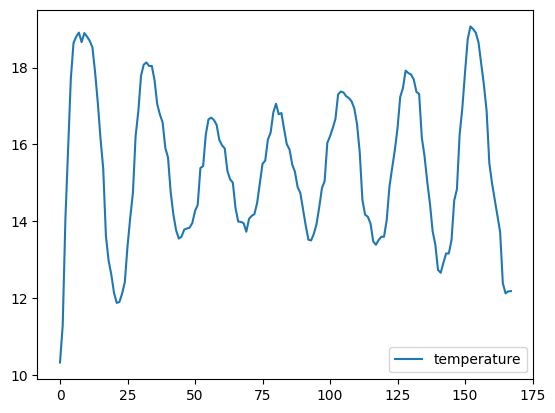

In [26]:
plot_predictions(model, sets_limited[1][0][:1], 24 * 7, just=["temperature"])

## Save model

In [10]:
with open("../model.pkl", "wb") as f:
    cloudpickle.dump(best_model, f, protocol=5)

## Base

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.727264     0.708439      3.571101       3.668525
1        future_humidity  0.343343     0.325413     12.857302      13.084380
2  future_wind_direction  0.188226     0.149184     85.428453      87.556484
3      future_wind_speed  0.244990     0.211681      1.533351       1.564718
4   future_precipitation  0.045248     0.011436      0.458758       0.485749
5           future_light  0.390470     0.365260  19047.985998   19309.773997
6                    all  0.323257     0.295235   3191.972494    3236.022309


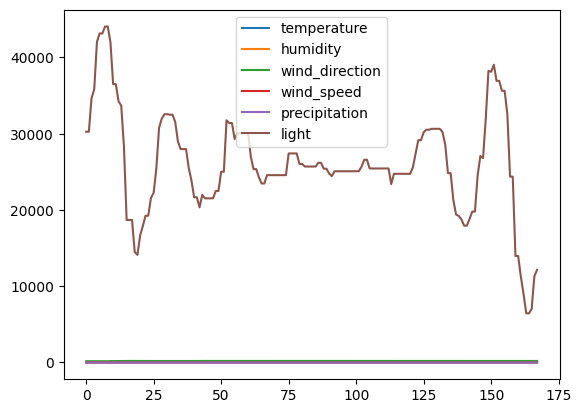

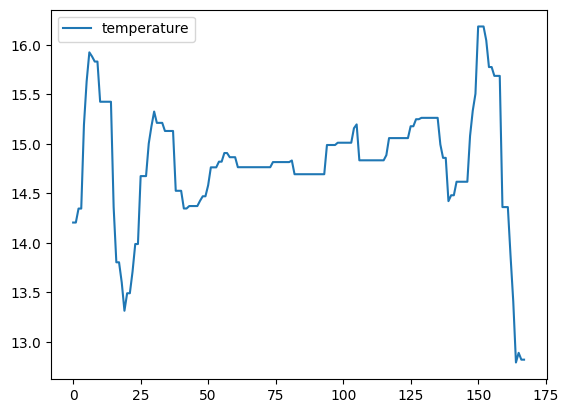

In [11]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(max_depth=5, random_state=SEED))
preprocessor = Pipeline([
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(split_time)),
])
model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])
fit_and_score(model, sets_limited)

plot_predictions(model, sets_limited[1][0][:1], 24 * 7)
plot_predictions(model, sets_limited[1][0][:1], 24 * 7, just=["temperature"])

## Models

### HistGradientBoostringRegressor

In [24]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(random_state=SEED))
model = Pipeline([
    ("preprocessor", preprocessor_base),
    ("model", model)
])
params = {
    "model__estimator__max_depth": range(5, 15),
    "model__estimator__learning_rate": [0.05, 0.1, 0.2,],
    "model__estimator__min_samples_leaf": range(30, 50),
    "model__estimator__max_iter": [10, 25, 50, 100, 200],
    "model__estimator__max_features": [0.2, 0.4, 0.6, 0.8, 1.0],
    "model__estimator__max_leaf_nodes": [None, *range(21, 60, 5)]
}
search = RandomizedSearchCV(model, params, random_state=SEED)

search_sets = sets_limited
search.fit(*search_sets[0])

print(search.best_estimator_)
compute_metrics(search.best_estimator_, [("train", *(search_sets[0])), ("validate", *(search_sets[1]))])

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('NaN_dropper',
                                  FunctionTransformer(func=<function drop_nan at 0x70749f0ce2a0>)),
                                 ('time_spliter',
                                  FunctionTransformer(func=<function split_time at 0x70749f0ceac0>))])),
                ('model',
                 MultiOutputRegressor(estimator=HistGradientBoostingRegressor(learning_rate=0.05,
                                                                              max_depth=8,
                                                                              max_features=0.6,
                                                                              max_iter=200,
                                                                              max_leaf_nodes=None,
                                                                              min_samples_leaf=33,
                                                              

In [27]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(max_depth=10, random_state=SEED))
model = Pipeline([
    ("preprocessor", preprocessor_base),
    ("model", model)
])
fit_and_score(model, sets_limited)

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.753675     0.735235      3.393797       3.495880
1        future_humidity  0.411155     0.383551     12.175338      12.507850
2  future_wind_direction  0.222302     0.173369     83.616192      86.303079
3      future_wind_speed  0.282842     0.238751      1.494421       1.537618
4   future_precipitation  0.089407     0.009037      0.448024       0.486338
5           future_light  0.552491     0.518443  16321.222257   16819.118183
6                    all  0.385312     0.343064   2737.058338    2820.574824


In [28]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(max_depth=10, random_state=SEED))
model = Pipeline([
    ("preprocessor", preprocessor_no_year),
    ("model", model)
])
fit_and_score(model, sets_limited)

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.751447     0.732615      3.409110       3.513134
1        future_humidity  0.438216     0.405198     11.892280      12.286279
2  future_wind_direction  0.179190     0.129328     85.902597      88.572257
3      future_wind_speed  0.222850     0.174954      1.555671       1.600751
4   future_precipitation  0.067687     0.001879      0.453335       0.488091
5           future_light  0.552210     0.521504  16326.331986   16765.577187
6                    all  0.368600     0.327580   2738.257497    2812.006283


In [29]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(max_depth=10, random_state=SEED))
model = Pipeline([
    ("preprocessor", preprocessor_cyclic),
    ("model", model)
])
fit_and_score(model, sets_limited)

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.764319     0.744131      3.319660       3.436648
1        future_humidity  0.409958     0.380340     12.187705      12.540389
2  future_wind_direction  0.225820     0.172105     83.426886      86.369038
3      future_wind_speed  0.296275     0.253437      1.480358       1.522713
4   future_precipitation  0.110147     0.013632      0.442892       0.485209
5           future_light  0.535983     0.501571  16619.521657   17111.217271
6                    all  0.390417     0.344203   2786.729860    2869.261878


## Scaled

In [30]:
model = MultiOutputRegressor(HistGradientBoostingRegressor(max_depth=10, random_state=SEED))
model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", model)
])
fit_and_score(model, sets_limited)

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.753675     0.735235      3.393797       3.495881
1        future_humidity  0.411155     0.383551     12.175338      12.507850
2  future_wind_direction  0.222302     0.173369     83.616192      86.303079
3      future_wind_speed  0.282842     0.238758      1.494421       1.537611
4   future_precipitation  0.089407     0.009037      0.448024       0.486338
5           future_light  0.552491     0.518443  16321.222257   16819.118183
6                    all  0.385312     0.343065   2737.058338    2820.574823


## Random forest

In [31]:
model = MultiOutputRegressor(RandomForestRegressor(max_depth=5, random_state=SEED))
model = Pipeline([
    ("preprocessor", preprocessor_base),
    ("model", model)
])
fit_and_score(model, sets_limited)

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.630086     0.624016      4.158932       4.165924
1        future_humidity  0.166666     0.168395     14.484051      14.527558
2  future_wind_direction  0.098669     0.091167     90.017545      90.492457
3      future_wind_speed  0.139951     0.130757      1.636541       1.643068
4   future_precipitation  0.046087    -0.006235      0.458557       0.490071
5           future_light  0.180602     0.183466  22085.089745   21901.122836
6                    all  0.210343     0.198594   3699.307562    3668.740319


## SVM

In [ ]:
model = MultiOutputRegressor(SVR(kernel="rbf"))
model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", model)
])
fit_and_score(model, sets_ultra_limited)

In [ ]:
model = MultiOutputRegressor(SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1))
model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", model)
])
fit_and_score(model, sets_ultra_limited)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.832052     0.751174    2.876484       3.543392
1       future_humidity  0.300147     0.124008   12.311595      13.630608
2       future_wind_dir  0.196091     0.134977   82.280619      84.663419
3     future_wind_speed  0.364929     0.039790    1.619107       1.962438
4  future_precip_past1h  0.155923    -0.053571    0.407641       0.471770
5                   all  0.369828     0.199275   19.899089      20.854325


In [ ]:
model = MultiOutputRegressor(SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1))
model = Pipeline([
    ("preprocessor", preprocessor_cyclic_scaled),
    ("model", model)
])
fit_and_score(model, sets_ultra_limited)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.888907     0.741812    2.339474       3.609437
1       future_humidity  0.456024     0.127411   10.854277      13.604105
2       future_wind_dir  0.319223     0.192479   75.717537      81.801068
3     future_wind_speed  0.616982    -0.030628    1.257402       2.033123
4  future_precip_past1h  0.330392    -0.176445    0.363075       0.498522
5                   all  0.522306     0.170926   18.106353      20.309251


In [ ]:
model = MultiOutputRegressor(SVR(kernel="poly", degree=2))
model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", model)
])
fit_and_score(model, sets_ultra_limited)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.641552     0.638357    4.202299       4.271798
1       future_humidity  0.071089     0.060732   14.183976      14.114315
2       future_wind_dir  0.060186     0.078807   88.964118      87.368995
3     future_wind_speed  0.043637     0.023790    1.986899       1.978720
4  future_precip_past1h -0.003703    -0.006978    0.444518       0.461220
5                   all  0.162552     0.158942   21.956362      21.639010


In [ ]:
model = MultiOutputRegressor(SVR(kernel="poly", degree=3))
model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", model)
])
fit_and_score(model, sets_ultra_limited)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.661929     0.630511    4.081108       4.317892
1       future_humidity  0.071806     0.029158   14.178501      14.349585
2       future_wind_dir  0.061817     0.071134   88.886920      87.732086
3     future_wind_speed  0.098639    -0.029627    1.928918       2.032136
4  future_precip_past1h -0.001548    -0.006538    0.444040       0.461120
5                   all  0.178529     0.138928   21.903898      21.778564


## Untrained dates

In [ ]:
for include_year in [True, False]:
    pipeline_old_dates = Pipeline([
        ("before_date_dropper", FunctionTransformer(lambda X: drop_before(X, datetime(2025, 1, 1) - timedelta(days=365*2)))),
        ("after_date_dropper", FunctionTransformer(lambda X: drop_after(X, datetime(2025, 1, 1)))),
        ("NaN_dropper", FunctionTransformer(drop_nan)),
    ])

    pipeline_new_dates = Pipeline([
        ("before_date_dropper", FunctionTransformer(lambda X: drop_before(X, datetime(2025, 1, 1)))),
        ("NaN_dropper", FunctionTransformer(drop_nan)),
    ])

    print(f"===== OLD {"with" if include_year else "without"} year =====")
    preprocessor = Pipeline([
        ("NaN_dropper", FunctionTransformer(drop_nan)),
        ("time_spliter", FunctionTransformer(lambda X: split_time(X, year=include_year, make_cyclic=True))),
    ])
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", best_model)
    ])
    fit_and_score(model, get_sets(pipeline_old_dates.fit_transform(raw_data_limited), seed=SEED))

    print(f"===== NEW {"with" if include_year else "without"} year =====")
    compute_metrics(model, get_sets(pipeline_new_dates.fit_transform(raw_data_limited), seed=SEED))

===== OLD with year =====
                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.818970     0.754616    2.797141       3.258857
1       future_humidity  0.516786     0.325692    9.994784      11.984366
2       future_wind_dir  0.408895     0.192762   77.665172      93.978643
3     future_wind_speed  0.532725     0.377738    1.150237       1.344285
4  future_precip_past1h  0.399821     0.002544    0.437371       0.679757
5                   all  0.535439     0.330670   18.408941      22.249182
===== NEW with year =====
                feature   r2_test  RMSE_test
0       future_temp_dry  0.697021   3.872674
1       future_humidity  0.165446  13.380960
2       future_wind_dir -0.038490  93.620812
3     future_wind_speed -0.317598   2.312900
4  future_precip_past1h -0.115300   0.452081
5                   all  0.078216  22.727886
===== OLD without year =====
                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       futu

## Cyclic wind direction

In [ ]:
preprocessor = Pipeline([
    ("NaN_dropper", FunctionTransformer(drop_nan)),
    ("time_spliter", FunctionTransformer(lambda X: split_time(X, year=False, make_cyclic=True))),
    ("wind_dir_cyclic", FunctionTransformer(lambda X: encode_cyclic(X, "wind_direction", 0, 360, remove_old=False))),
    ("wind_dir_dropper", FunctionTransformer(lambda X: drop_columns(X, ["wind_direction"])))
])
model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_model)
])

fit_and_score(model, sets_limited)

                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.903721     0.817992    2.177906       3.030517
1       future_humidity  0.621295     0.321732    9.056522      11.994044
2       future_wind_dir  0.559667     0.236976   60.895429      79.515360
3     future_wind_speed  0.523969     0.232649    1.401788       1.754324
4  future_precip_past1h  0.428290    -0.031745    0.335486       0.466858
5                   all  0.607388     0.315521   14.773426      19.352221
                feature  r2_train  r2_validate  RMSE_train  RMSE_validate
0       future_temp_dry  0.904571     0.814916    2.168269       3.056017
1       future_humidity  0.627849     0.322205    8.977818      11.989858
2       future_wind_dir  0.568715     0.240130   60.266504      79.350864
3     future_wind_speed  0.532557     0.216689    1.389085       1.772474
4  future_precip_past1h  0.388324    -0.035456    0.347014       0.467697
5                   all  0.604403     

## Negative rain

In [27]:
X = sets_limited[0][0]
X[X["precipitation"] < 0]

,time,temperature,humidity,wind_direction,wind_speed,precipitation,light,prediction_offset


In [20]:
predictions = pd.DataFrame(fitted_best_model.predict(sets_limited[1][0]), columns=sets_limited[1][1].columns)
predictions[predictions["future_precipitation"] < 0]

,future_temperature,future_humidity,future_wind_direction,future_wind_speed,future_precipitation,future_light
40,16.801148,59.915145,211.247664,2.754623,-0.018734,74348.781439
52,4.694171,98.527174,15.080222,0.196341,-0.052628,3285.728716
182,-0.539749,86.223501,222.857933,1.989460,-0.010563,2777.542398
303,8.082751,84.714575,118.489603,0.991569,-0.029746,5556.306675
307,7.321073,78.915191,221.195304,2.430922,-0.001336,9991.272432
...,...,...,...,...,...,...
15658,15.684738,78.518994,244.163645,1.759136,-0.000039,13392.643045
15759,8.483973,42.195768,117.263098,4.749926,-0.026458,63165.959950
15928,12.348814,90.533954,223.401767,1.656792,-0.007459,5606.682130
15932,2.290093,89.909598,131.905559,2.155876,-0.008684,-45.921087


In [29]:
def add_is_raining(X):
    X["is_raining"] = (X["precipitation"] > 0).astype(int)
    return X

model = Pipeline([
    ("preprocessor", preprocessor_cyclic),
    ("is_raining", FunctionTransformer(add_is_raining)),
    ("model", best_model),
])

fit_and_score(model, sets_limited)

predictions = pd.DataFrame(model.predict(sets_limited[1][0]), columns=sets_limited[1][1].columns)
predictions[predictions["future_precipitation"] < 0]

                 feature  r2_train  r2_validate    RMSE_train  RMSE_validate
0     future_temperature  0.827760     0.784386      2.837909       3.154753
1        future_humidity  0.528762     0.439326     10.891829      11.928600
2  future_wind_direction  0.341205     0.212205     76.959122      84.251374
3      future_wind_speed  0.425666     0.310329      1.337358       1.463544
4   future_precipitation  0.109948     0.013523      0.442941       0.485236
5           future_light  0.664846     0.590524  14124.527264   15509.350469
6                    all  0.483031     0.391715   2369.499404    2601.772329


,future_temperature,future_humidity,future_wind_direction,future_wind_speed,future_precipitation,future_light
40,15.593318,62.560286,179.380169,2.914283,-0.000412,57850.250758
44,24.041862,59.533654,124.297988,2.731682,-0.023709,42754.612256
62,15.474794,70.350581,74.379461,1.578022,-0.016668,11368.031058
155,19.329919,64.416804,105.428110,2.504460,-0.000212,47696.516161
167,17.299214,77.534123,221.388810,2.411751,-0.011767,31072.202662
...,...,...,...,...,...,...
15666,13.821909,87.847154,183.342010,2.126496,-0.013480,5783.848590
15683,14.253629,78.164979,212.870535,2.195313,-0.006287,10142.891979
15700,10.307117,70.883008,212.193731,2.176800,-0.000526,52883.105972
15743,14.705856,78.139348,254.261904,1.880522,-0.008474,2073.208971
